# Part 7a U55C: Coyote Bitstream Generation

This notebook takes an existing hls4ml sweep from the exploration notebook and stages a Coyote U55C hardware build around it.


In [1]:
from __future__ import annotations

import csv
import hashlib
import json
import math
import os
import re
import shutil
import subprocess
import sys
import time
from pathlib import Path

import numpy as np

WORKSPACE = Path.cwd()
ML_BASELINE = WORKSPACE.parent
COYOTE_ROOT = Path("/pub/scratch/sdeheredia/Coyote")
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))
if str(ML_BASELINE) not in sys.path:
    sys.path.insert(0, str(ML_BASELINE))

DEFAULT_ITERATION_ROOT = WORKSPACE / "artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4"
DEFAULT_FOLD = 0
DEFAULT_HLS_SWEEP = "hls_1e918f3210d4"
ABI = {
    "img_size": 512,
    "pixels_per_sample": 512 * 512,
    "axi_data_bits": 512,
    "fixed_width": 16,
    "fixed_integer": 6,
    "fixed_fraction": 10,
    "pixels_per_beat": 32,
    "beats_per_sample": 8192,
    "input_bytes_per_sample": 512 * 512 * 2,
    "output_bytes_per_sample": 64,
}

def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text())

def write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def sha256_tree(root: Path, patterns=(".cpp", ".h", ".hpp", ".svh", ".txt", ".cmake", "CMakeLists.txt")) -> str:
    h = hashlib.sha256()
    root = Path(root)
    if not root.exists():
        return ""
    for path in sorted(p for p in root.rglob("*") if p.is_file()):
        if path.name == "CMakeLists.txt" or any(path.name.endswith(pat) for pat in patterns):
            h.update(str(path.relative_to(root)).encode())
            h.update(path.read_bytes())
    return h.hexdigest()

def run(cmd: list[str], cwd: Path, log_path: Path | None = None) -> subprocess.CompletedProcess:
    print("$", " ".join(map(str, cmd)))
    proc = subprocess.run(cmd, cwd=str(cwd), text=True, capture_output=True)
    if log_path is not None:
        log_path.parent.mkdir(parents=True, exist_ok=True)
        log_path.write_text("STDOUT\n" + proc.stdout + "\nSTDERR\n" + proc.stderr)
    if proc.stdout:
        print(proc.stdout[-4000:])
    if proc.stderr:
        print(proc.stderr[-4000:])
    proc.check_returncode()
    return proc

def sigmoid(x):
    x = np.asarray(x, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-x))

def clean_rows(csv_path: Path) -> list[dict]:
    if not Path(csv_path).exists():
        return []
    with Path(csv_path).open(newline="") as handle:
        rows = [row for row in csv.DictReader(handle)]
    return [row for row in rows if row.get("sample_index") not in ("sample_index", "", None)]

def binary_loss(label: float, prob: float) -> float:
    p = float(np.clip(prob, 1e-7, 1.0 - 1e-7))
    return float(-(label * np.log(p) + (1.0 - label) * np.log(1.0 - p)))

def rows_from_logits(meta_rows: list[dict], logits: np.ndarray) -> list[dict]:
    probs = sigmoid(logits)
    rows = []
    for i, (meta, logit, prob) in enumerate(zip(meta_rows, logits, probs)):
        label = int(meta["class_label"])
        pred = int(prob >= 0.5)
        rows.append({
            "sample_index": i,
            "sample_id": meta.get("sample_id", ""),
            "app_name": meta.get("app_name", ""),
            "class_label": label,
            "class_name": meta.get("class_name", "standalone" if label else "benign"),
            "ro_count": meta.get("ro_count", ""),
            "bitstream_path": meta.get("bitstream_path", ""),
            "logit": f"{float(logit):.9f}",
            "probability": f"{float(prob):.9f}",
            "predicted_label": pred,
            "correct": int(pred == label),
            "per_sample_bce_loss": f"{binary_loss(label, prob):.9f}",
            "per_sample_log_loss": f"{binary_loss(label, prob):.9f}",
        })
    return rows

def write_csv(path: Path, rows: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        path.write_text("")
        return
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


In [2]:
ITERATION_ROOT = DEFAULT_ITERATION_ROOT
SELECTED_FOLD = DEFAULT_FOLD
REQUESTED_HLS_SWEEP = DEFAULT_HLS_SWEEP

def discover_sweeps(iteration_root: Path, fold: int) -> list[dict]:
    out = []
    for sweep in sorted((iteration_root / "hls_sweeps").glob("*")):
        project = sweep / f"fold_{fold}" / "project"
        conv = project / "conversion_manifest.json"
        if conv.exists() and (project / "firmware").is_dir():
            payload = read_json(conv)
            out.append({
                "name": sweep.name,
                "path": sweep,
                "project": project,
                "project_name": payload["project_name"],
                "hls_fingerprint": payload.get("hls_fingerprint", ""),
            })
    return out

sweeps = discover_sweeps(ITERATION_ROOT, SELECTED_FOLD)
if not sweeps:
    raise FileNotFoundError(f"No generated hls4ml projects found below {ITERATION_ROOT}")
selected = next((s for s in sweeps if s["name"] == REQUESTED_HLS_SWEEP), sweeps[0])

HLS_SWEEP_ROOT = selected["path"]
HLS_PROJECT_DIR = selected["project"]
PROJECT_NAME = selected["project_name"]
FOLD_DIR = ITERATION_ROOT / f"fold_{SELECTED_FOLD}"
PARITY_DIR = HLS_SWEEP_ROOT / f"fold_{SELECTED_FOLD}" / "parity"
U55C_ROOT = HLS_SWEEP_ROOT / f"fold_{SELECTED_FOLD}" / "u55c_deployment"
PREPARED_INPUTS_DIR = U55C_ROOT / "prepared_inputs"
STAGED_HW_DIR = U55C_ROOT / "coyote_hw"
STAGED_SW_DIR = U55C_ROOT / "coyote_sw"
VALIDATION_DIR = HLS_SWEEP_ROOT / f"fold_{SELECTED_FOLD}" / "u55c_validation"

print("iteration root:", ITERATION_ROOT)
print("selected fold:", SELECTED_FOLD)
print("selected sweep:", selected["name"])
print("hls project:", HLS_PROJECT_DIR)
print("artifact root:", U55C_ROOT)
print("available sweeps:", [s["name"] for s in sweeps])


iteration root: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4
selected fold: 0
selected sweep: hls_1e918f3210d4
hls project: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_1e918f3210d4/fold_0/project
artifact root: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_1e918f3210d4/fold_0/u55c_deployment
available sweeps: ['hls_1e918f3210d4', 'hls_38a358795f82', 'hls_b1649c98dace', 'hls_f7e981d53115', 'rf1_hls_4c15bcf2f51a']


## Inspect Selected Fold And Sweep



## training metrics: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/fold_0/metrics_summary.json
accuracy: 0.9166666666666666
balanced_accuracy: 0.9166666666666666
bce_loss: 0.32483652234077454
benign_log_loss: 0.30171553901359544
benign_mean_score: 0.2450999617576599
brier_score: 0.08897900581359863
candidate: cnn_small_hls_opt_img512
confusion_matrix: [[22, 2], [2, 22]]
ece: 0.1755655126956602
f1: 0.9166666666666666
fingerprint: 0cfa065db9d45e24d1cfbb0417fe9c4b5384f6e503273f174c064817881601c2
fold: 0
log_loss: 0.32483649986310464
mcc: 0.8333333333333334
optimal_accuracy: 0.9375
optimal_f1: 0.9333333333333333
optimal_threshold: 0.5530828833580017
pr_auc: 0.9874283325370281
precision: 0.9166666666666666
recall: 0.9166666666666666
roc_auc: 0.9861111111111112
stage: pruned_qat
standalone_log_loss: 0.34795746071261385
standalone_mean_score: 0.7200924754142761

## hls parity: /pub/scrat

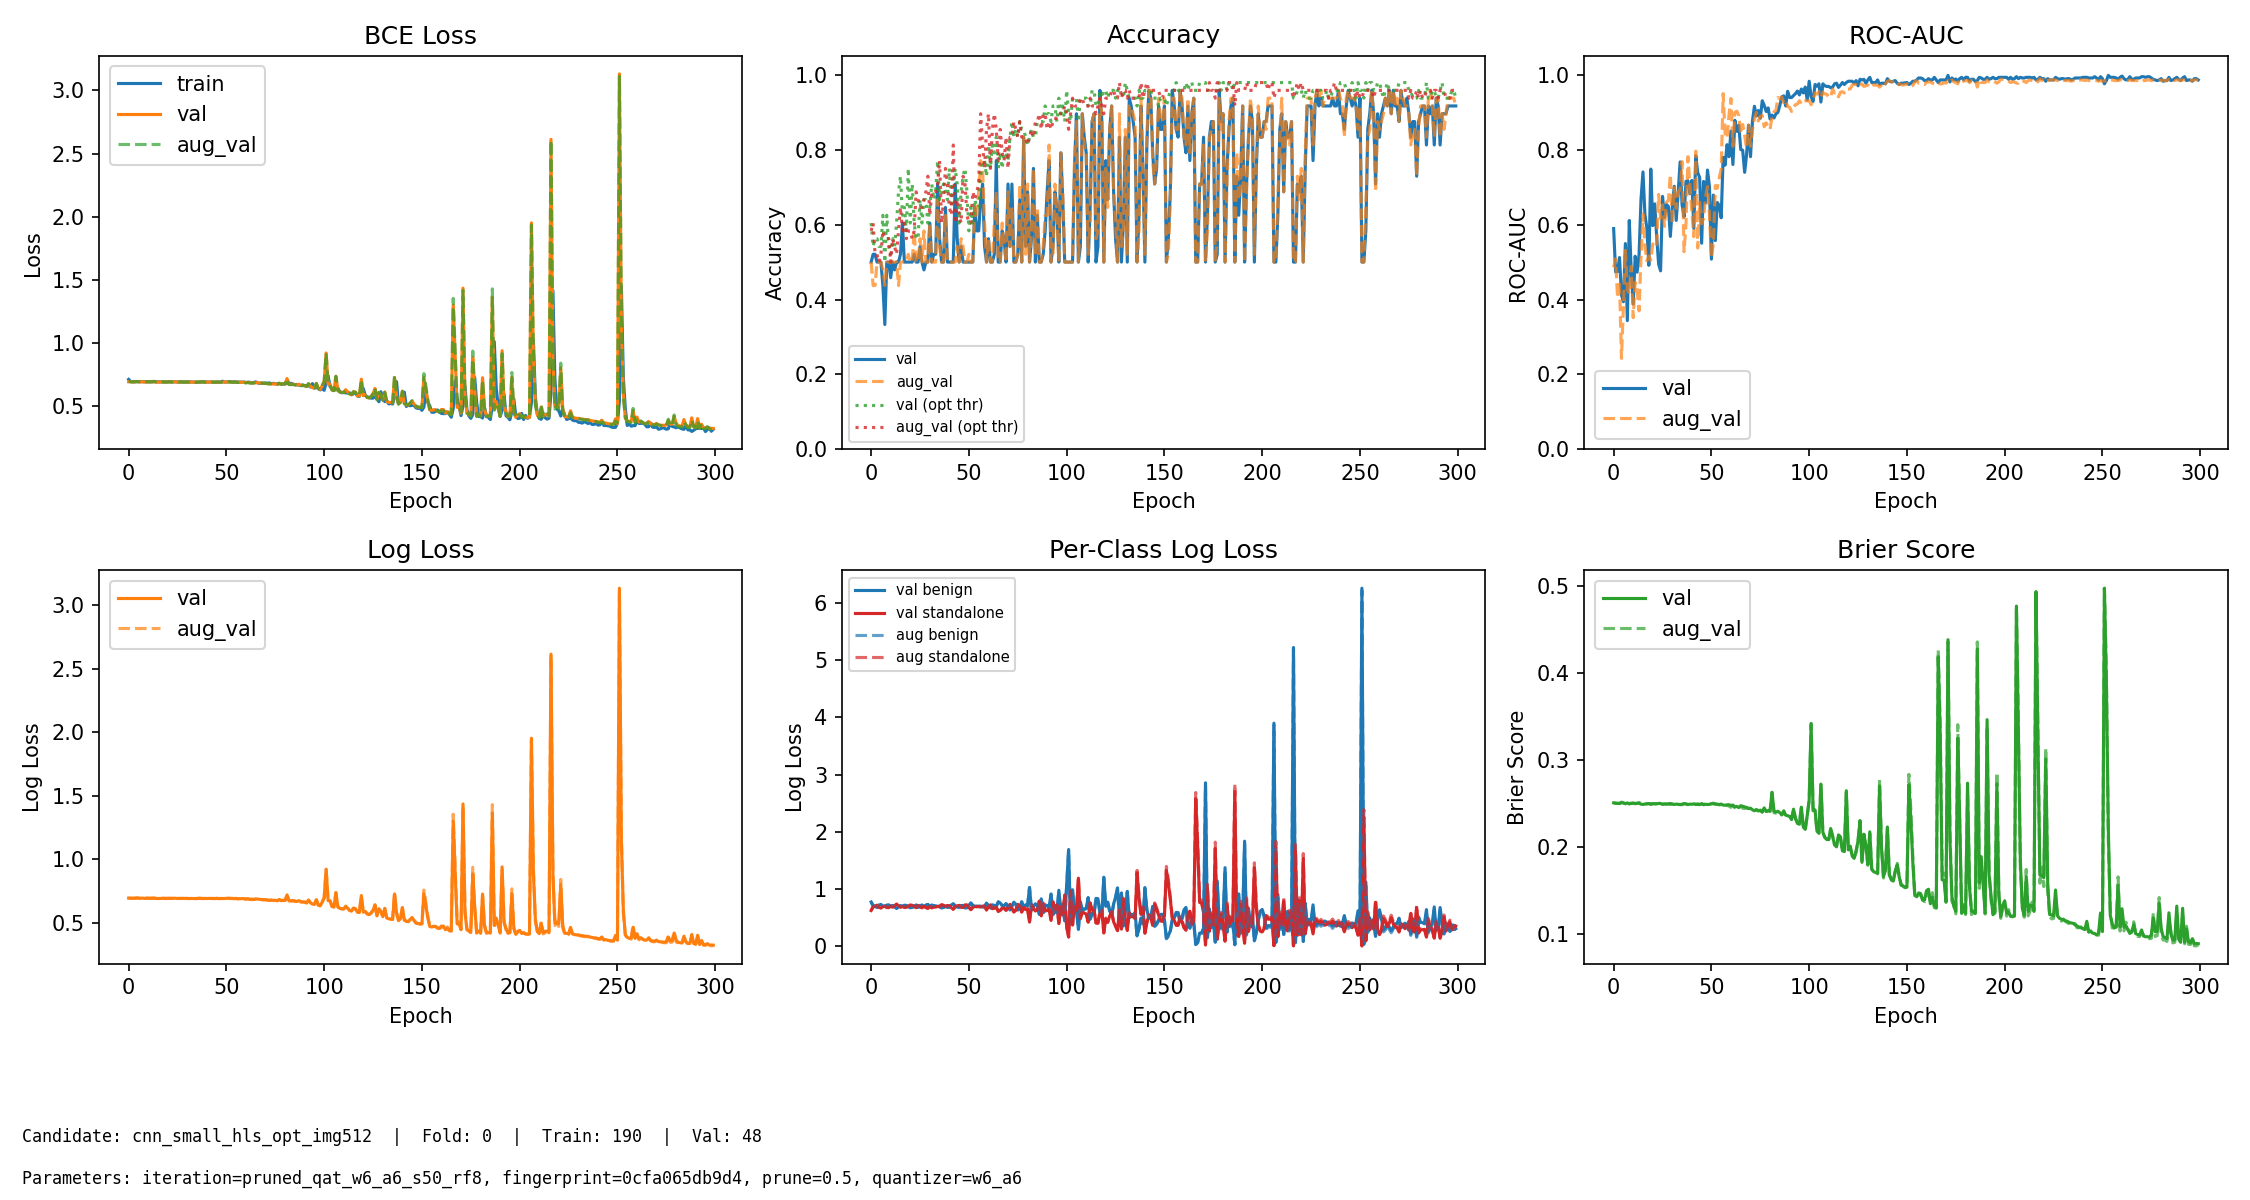

/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/fold_0/final_evaluation_plots.png


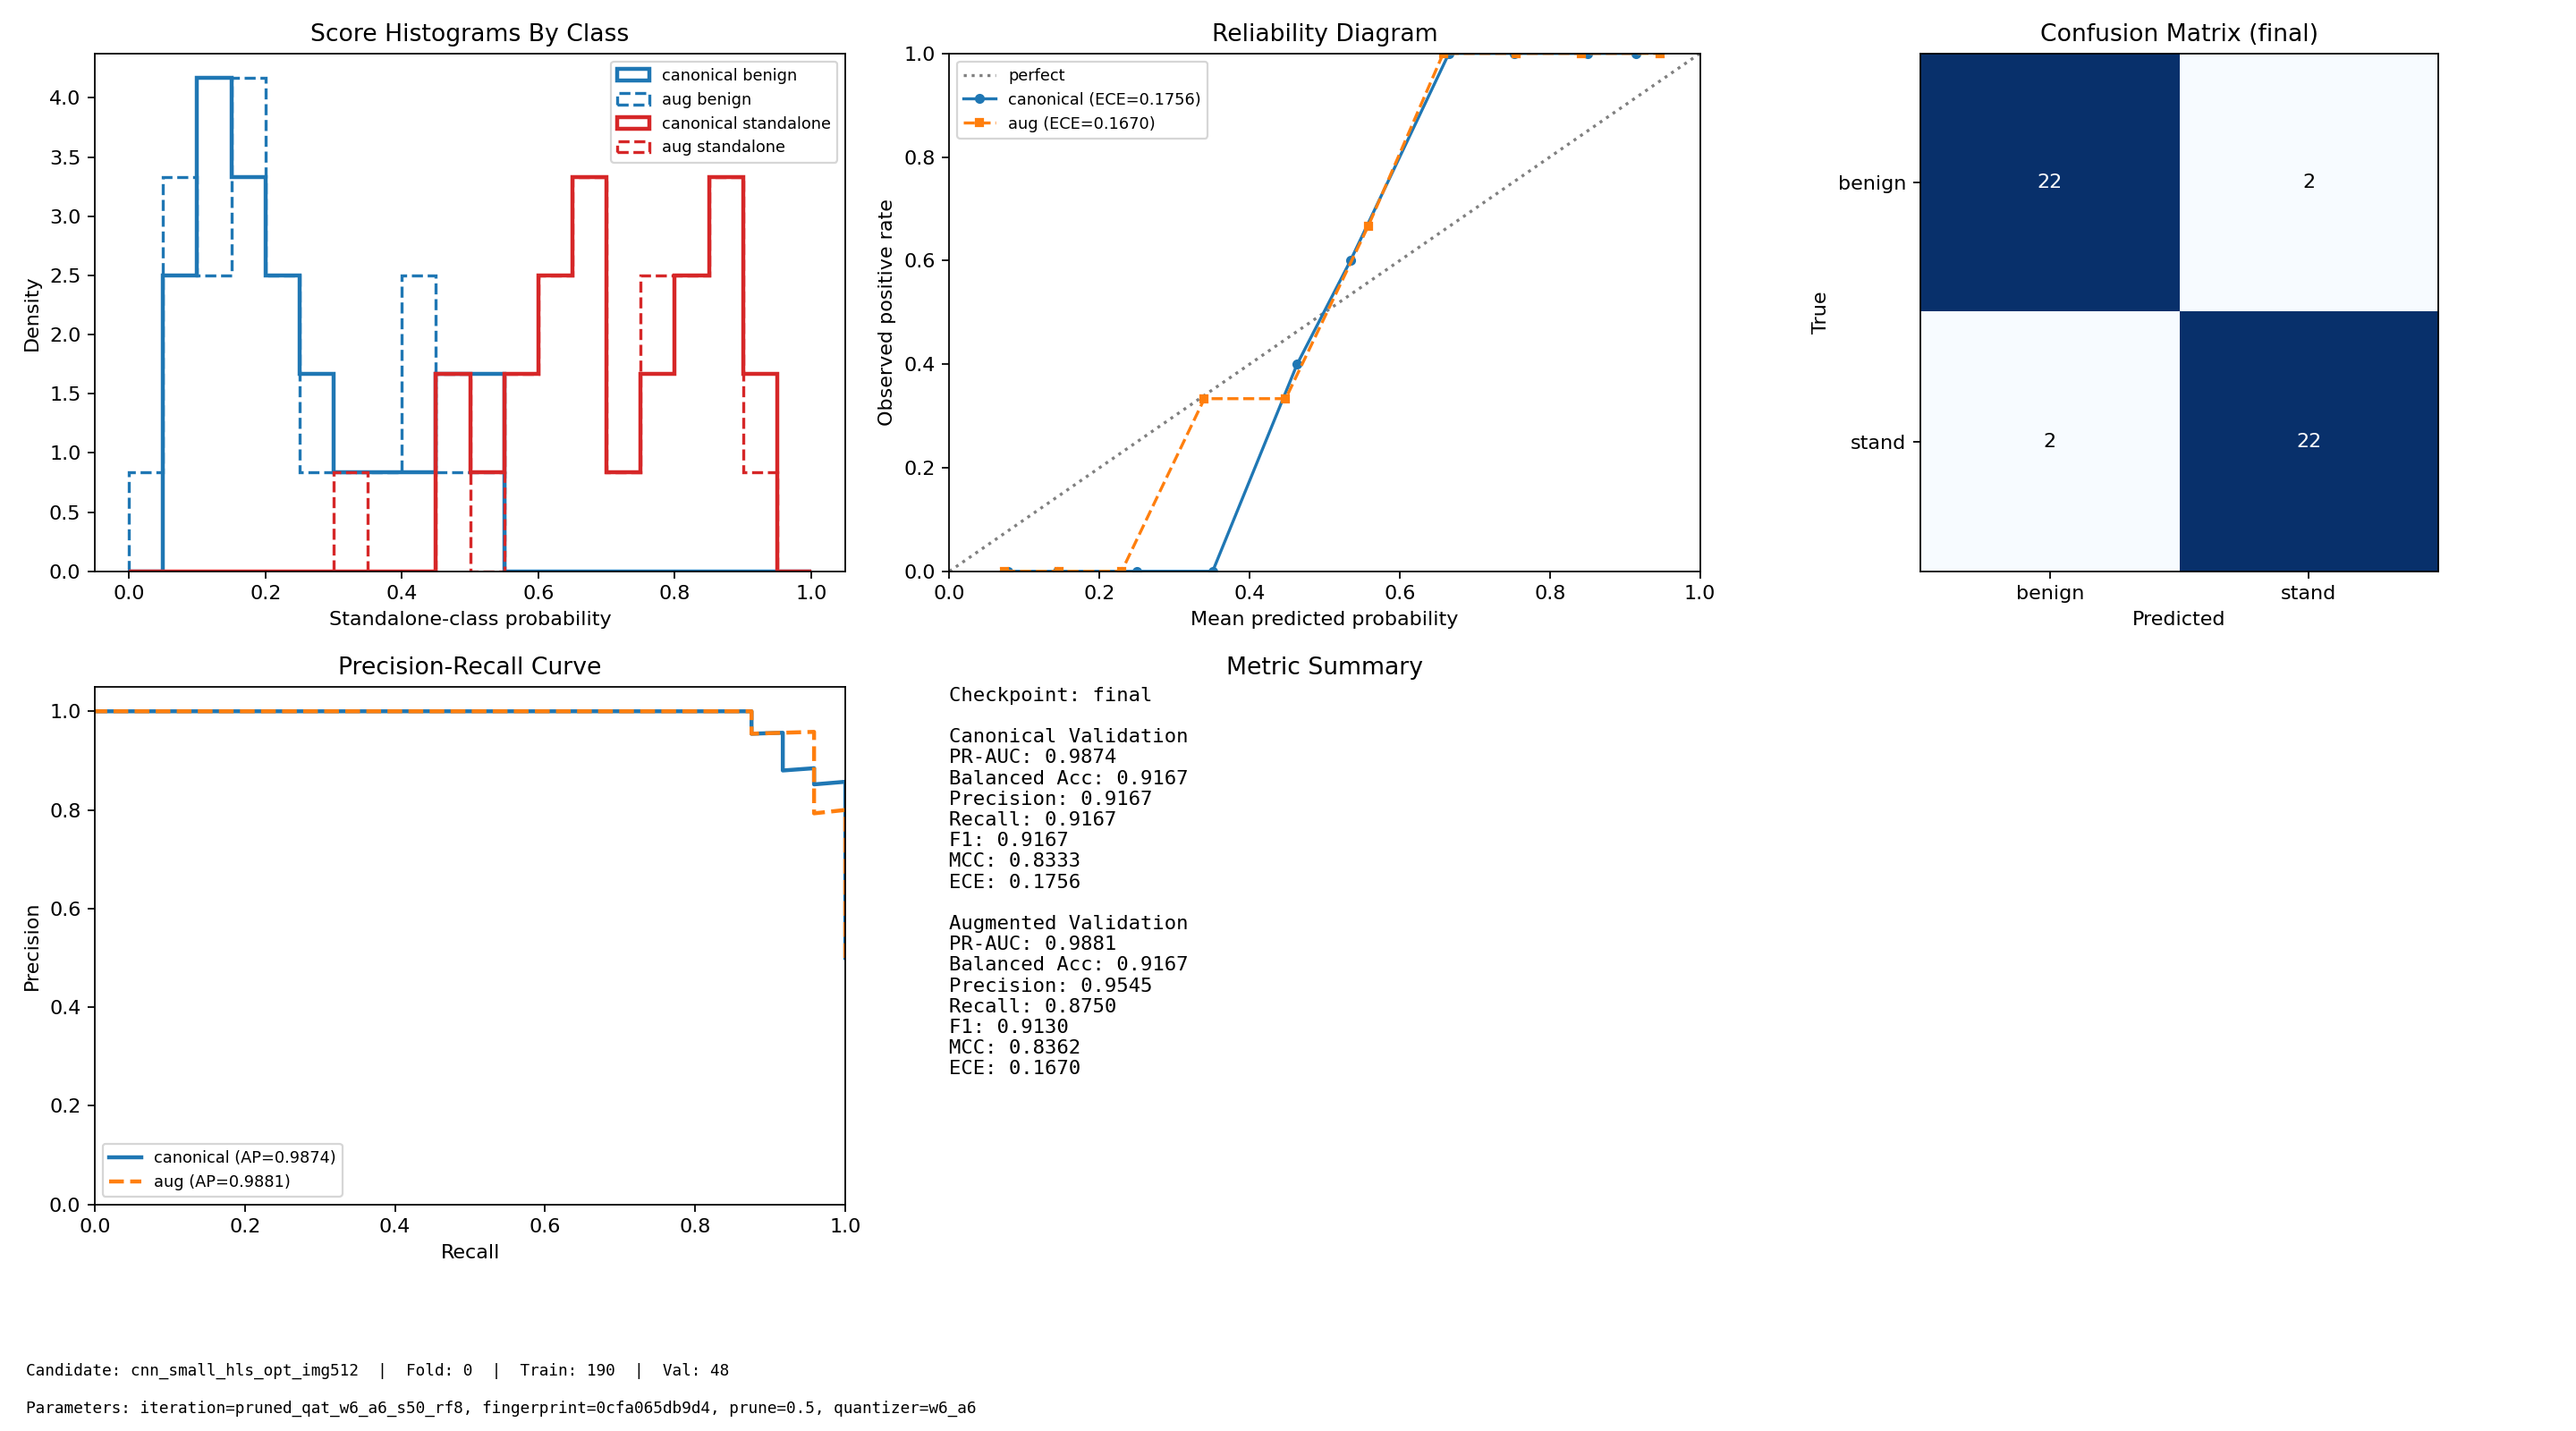

/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_1e918f3210d4/fold_0/project/hls4ml_model.png


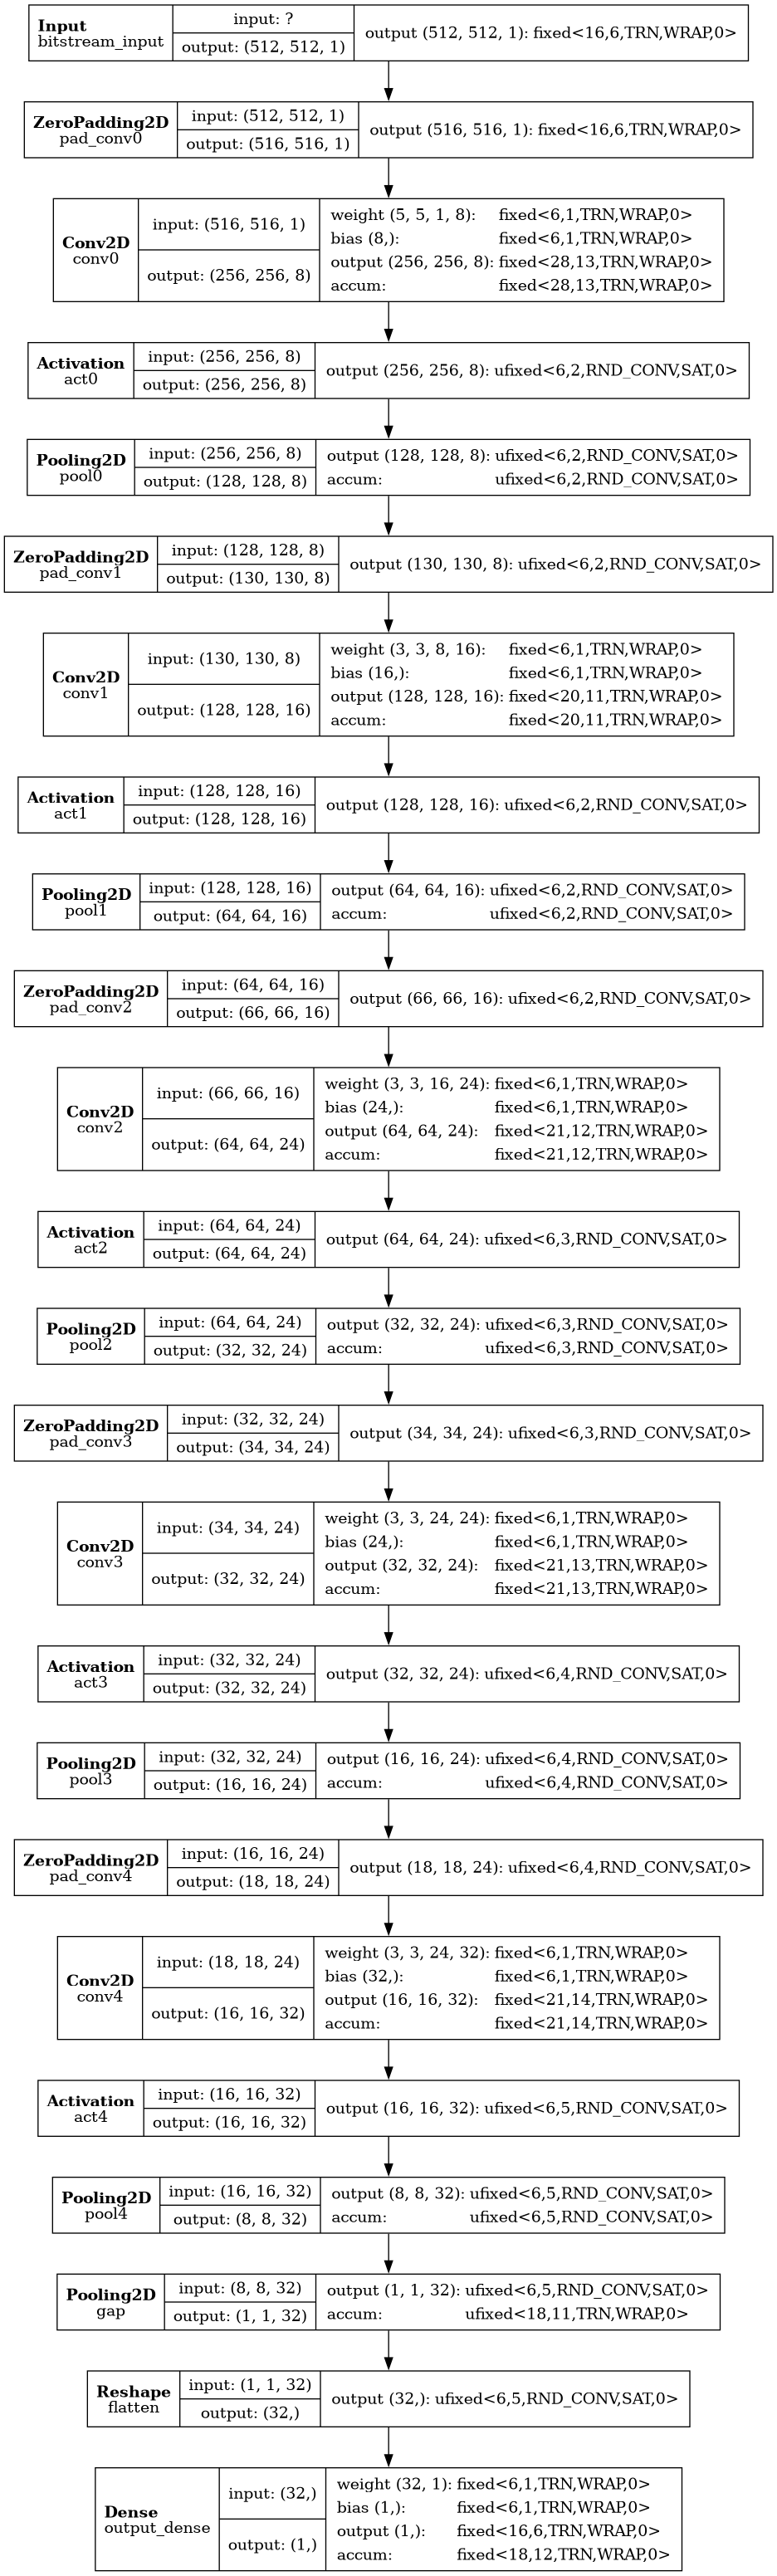

In [3]:
from IPython.display import Image, display

for label, path in [
    ("training metrics", FOLD_DIR / "metrics_summary.json"),
    ("hls parity", PARITY_DIR / "summary.json"),
    ("hls config", HLS_PROJECT_DIR / "hls4ml_config.yml"),
]:
    print(f"\n## {label}: {path}")
    if path.exists():
        if path.suffix == ".json":
            payload = read_json(path)
            for key in list(payload)[:24]:
                print(f"{key}: {payload[key]}")
        else:
            print(path.read_text()[:5000])
    else:
        print("missing")

for path in [
    FOLD_DIR / "training_curves.png",
    FOLD_DIR / "final_evaluation_plots.png",
    HLS_PROJECT_DIR / "hls4ml_model.png",
    PARITY_DIR / "qkeras_final_evaluation_plots.png",
    PARITY_DIR / "hls_final_evaluation_plots.png",
    HLS_SWEEP_ROOT / f"fold_{SELECTED_FOLD}" / "layer_trace" / "layer_divergence.png",
]:
    if path.exists():
        print(path)
        display(Image(filename=str(path)))


## Prepare Fixed Validation Inputs


In [4]:
def load_split_rows(kind: str) -> list[dict]:
    path = ITERATION_ROOT / "splits" / f"fold_{SELECTED_FOLD}_{kind}.csv"
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))

def bitstream_to_sequence(bin_path: Path, sequence_length: int, invert: bool = True) -> np.ndarray:
    data = np.fromfile(bin_path, dtype=np.uint8)
    if len(data) <= sequence_length:
        window = np.zeros(sequence_length, dtype=np.uint8)
        window[:len(data)] = data
    else:
        indices = np.linspace(0, len(data) - 1, sequence_length, dtype=np.int64)
        window = data[indices]
    return 255 - window if invert else window

def sample_to_nhwc(row: dict) -> np.ndarray:
    bin_path = Path(row["_bitstream_dir"]) / row["bitstream_path"]
    seq = bitstream_to_sequence(bin_path, ABI["pixels_per_sample"], invert=True)
    return (seq.reshape(ABI["img_size"], ABI["img_size"]).astype(np.float32) / 255.0)[..., np.newaxis]

train_samples = load_split_rows("train")
val_samples = load_split_rows("val")
sample_ids = [row["sample_id"] for row in val_samples]

input_fingerprint = {
    "training_fingerprint": read_json(ITERATION_ROOT / "iteration_manifest.json").get("training_fingerprint"),
    "hls_fingerprint": selected["hls_fingerprint"],
    "fold": SELECTED_FOLD,
    "sample_ids": sample_ids,
    "abi": ABI,
}
manifest_path = PREPARED_INPUTS_DIR / "manifest.json"
csv_manifest_path = PREPARED_INPUTS_DIR / "manifest.csv"
cache_hit = manifest_path.exists() and read_json(manifest_path).get("fingerprint") == input_fingerprint

def fixed16_from_float(x: np.ndarray) -> np.ndarray:
    scale = 1 << ABI["fixed_fraction"]
    q = np.rint(np.asarray(x, dtype=np.float64) * scale)
    q = np.clip(q, -(1 << 15), (1 << 15) - 1).astype("<i2")
    return q

def float_from_fixed16(q: np.ndarray) -> np.ndarray:
    return q.astype(np.float32) / float(1 << ABI["fixed_fraction"])

if cache_hit:
    print("prepared input cache hit:", PREPARED_INPUTS_DIR)
else:
    PREPARED_INPUTS_DIR.mkdir(parents=True, exist_ok=True)
    rows = []
    all_x = []
    labels = []
    for idx, row in enumerate(val_samples):
        x = sample_to_nhwc(row).astype(np.float32)
        flat = x.reshape(-1)
        if flat.size != ABI["pixels_per_sample"]:
            raise ValueError(f"unexpected input size {flat.size}")
        fixed = fixed16_from_float(flat)
        blob = PREPARED_INPUTS_DIR / f"sample_{idx:04d}.bin"
        fixed.tofile(blob)
        all_x.append(x)
        labels.append(int(row["class_label"]))
        rows.append({
            "sample_index": idx,
            "sample_id": row.get("sample_id", ""),
            "class_label": int(row["class_label"]),
            "class_name": row.get("class_name", "standalone" if int(row["class_label"]) else "benign"),
            "app_name": row.get("app_name", ""),
            "ro_count": row.get("ro_count", ""),
            "bitstream_path": row.get("bitstream_path", ""),
            "input_path": str(blob),
            "input_sha256": sha256_file(blob),
            "input_bytes": blob.stat().st_size,
        })
    np.save(PREPARED_INPUTS_DIR / "x_norm.npy", np.stack(all_x))
    np.save(PREPARED_INPUTS_DIR / "labels.npy", np.asarray(labels, dtype=np.int32))
    write_csv(csv_manifest_path, rows)
    write_json(manifest_path, {
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "fingerprint": input_fingerprint,
        "csv_manifest": str(csv_manifest_path),
        "n_samples": len(rows),
        "input_bytes_per_sample": ABI["input_bytes_per_sample"],
    })
    print("wrote prepared inputs:", PREPARED_INPUTS_DIR)

x0 = np.load(PREPARED_INPUTS_DIR / "x_norm.npy")[0].reshape(-1)
q0 = np.fromfile(PREPARED_INPUTS_DIR / "sample_0000.bin", dtype="<i2")
decoded = float_from_fixed16(q0)
print("samples:", len(val_samples))
print("blob bytes:", (PREPARED_INPUTS_DIR / "sample_0000.bin").stat().st_size)
print("pack/unpack max abs error:", float(np.max(np.abs(decoded - x0))))


prepared input cache hit: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_1e918f3210d4/fold_0/u55c_deployment/prepared_inputs
samples: 48
blob bytes: 524288
pack/unpack max abs error: 0.0004863739013671875


## Stage Coyote Hardware And Host Sources


In [5]:
def rewrite_includes(text: str) -> str:
    text = text.replace('"nnet_utils/', '"').replace('"weights/', '"')
    lines = []
    for line in text.splitlines():
        if "#pragma HLS INTERFACE axis port=" in line:
            continue
        lines.append(line)
    return "\n".join(lines) + "\n"

def find_top_header(project_dir: Path, project_name: str) -> Path:
    header = project_dir / "firmware" / f"{project_name}.h"
    if header.exists():
        return header
    headers = sorted((project_dir / "firmware").glob("*.h"))
    matches = [h for h in headers if "defines" not in h.name and "parameters" not in h.name]
    if not matches:
        raise FileNotFoundError("could not find hls4ml top header")
    return matches[0]

def stage_kernel_sources() -> dict:
    firmware = HLS_PROJECT_DIR / "firmware"
    top_header = find_top_header(HLS_PROJECT_DIR, PROJECT_NAME)
    top_cpp = firmware / f"{top_header.stem}.cpp"
    if not top_cpp.exists():
        raise FileNotFoundError(top_cpp)

    kernel_dir = STAGED_HW_DIR / "src" / "hls" / "coyote_qkeras_infer"
    if kernel_dir.exists():
        shutil.rmtree(kernel_dir)
    kernel_dir.mkdir(parents=True, exist_ok=True)

    srcs = list(firmware.glob("*.h")) + list(firmware.glob("*.hpp")) + list(firmware.glob("*.cpp"))
    srcs += list((firmware / "nnet_utils").glob("*.h")) + list((firmware / "nnet_utils").glob("*.hpp"))
    srcs += list((firmware / "weights").glob("*.h"))
    for src in srcs:
        dst = kernel_dir / src.name
        dst.write_text(rewrite_includes(src.read_text(errors="ignore")))

    header = f'''
#pragma once

#include "ap_axi_sdata.h"
#include "ap_fixed.h"
#include "ap_int.h"
#include "hls_stream.h"

constexpr int AXI_DATA_BITS = 512;
constexpr int INPUT_PIXELS = 512 * 512;
constexpr int FIXED_WIDTH = 16;
constexpr int PIXELS_PER_BEAT = AXI_DATA_BITS / FIXED_WIDTH;
constexpr int INPUT_BEATS = INPUT_PIXELS / PIXELS_PER_BEAT;

typedef ap_axiu<AXI_DATA_BITS, 0, 0, 0> axi_s;
typedef ap_fixed<16,6> packed_input_t;

void coyote_qkeras_infer(hls::stream<axi_s> &s_axi_in, hls::stream<axi_s> &m_axi_out);
'''
    (kernel_dir / "coyote_qkeras_infer.hpp").write_text(header.strip() + "\n")

    wrapper = f'''
#include "coyote_qkeras_infer.hpp"
#include "{top_header.name}"
#include "{top_cpp.name}"

void coyote_qkeras_infer(hls::stream<axi_s> &s_axi_in, hls::stream<axi_s> &m_axi_out) {{
    #pragma HLS INTERFACE ap_ctrl_none port=return
    #pragma HLS INTERFACE axis register port=s_axi_in name=s_axi_in
    #pragma HLS INTERFACE axis register port=m_axi_out name=m_axi_out
    #pragma HLS DATAFLOW

    hls::stream<input_t> nn_in("nn_in");
    hls::stream<result_t> nn_out("nn_out");
    #pragma HLS STREAM variable=nn_in depth=1024
    #pragma HLS STREAM variable=nn_out depth=2

    for (int beat = 0; beat < INPUT_BEATS; ++beat) {{
        axi_s word = s_axi_in.read();
        for (int lane = 0; lane < PIXELS_PER_BEAT; ++lane) {{
            #pragma HLS PIPELINE II=1
            ap_int<FIXED_WIDTH> raw = word.data.range((lane + 1) * FIXED_WIDTH - 1, lane * FIXED_WIDTH);
            input_t item;
            item[0] = packed_input_t(raw);
            nn_in.write(item);
        }}
    }}

    {top_header.stem}(nn_in, nn_out);

    result_t y = nn_out.read();
    axi_s out_word;
    out_word.data = 0;
    out_word.keep = -1;
    out_word.last = 1;
    out_word.data.range(15, 0) = y[0].range(15, 0);
    m_axi_out.write(out_word);
}}
'''
    (kernel_dir / "coyote_qkeras_infer.cpp").write_text(wrapper.strip() + "\n")
    return {"kernel_dir": str(kernel_dir), "top_function": top_header.stem, "flattened_files": len(list(kernel_dir.iterdir()))}

def stage_coyote_hw_sw() -> dict:
    STAGED_HW_DIR.mkdir(parents=True, exist_ok=True)
    STAGED_SW_DIR.mkdir(parents=True, exist_ok=True)
    src_dir = STAGED_HW_DIR / "src"
    src_dir.mkdir(parents=True, exist_ok=True)

    kernel_info = stage_kernel_sources()
    (STAGED_HW_DIR / "CMakeLists.txt").write_text(f'''
cmake_minimum_required(VERSION 3.5)
set(CYT_DIR {COYOTE_ROOT})
set(CMAKE_MODULE_PATH ${{CMAKE_MODULE_PATH}} ${{CYT_DIR}}/cmake)
find_package(CoyoteHW REQUIRED)

project(u55c_qkeras_hls4ml_infer)
message("*** Coyote U55C QKeras hls4ml inference [Hardware] ***")

set(EN_STRM 1)
set(N_STRM_AXI 1)
set(EN_MEM 0)
set(N_REGIONS 1)

validation_checks_hw()
load_apps(VFPGA_C0_0 "src")
create_hw()
'''.strip() + "\n")

    (src_dir / "vfpga_top.svh").write_text('''
coyote_qkeras_infer_hls_ip inst_coyote_qkeras_infer(
    .s_axi_in_TDATA         (axis_host_recv[0].tdata),
    .s_axi_in_TKEEP         (axis_host_recv[0].tkeep),
    .s_axi_in_TLAST         (axis_host_recv[0].tlast),
    .s_axi_in_TSTRB         (0),
    .s_axi_in_TVALID        (axis_host_recv[0].tvalid),
    .s_axi_in_TREADY        (axis_host_recv[0].tready),

    .m_axi_out_TDATA        (axis_host_send[0].tdata),
    .m_axi_out_TKEEP        (axis_host_send[0].tkeep),
    .m_axi_out_TLAST        (axis_host_send[0].tlast),
    .m_axi_out_TSTRB        (),
    .m_axi_out_TVALID       (axis_host_send[0].tvalid),
    .m_axi_out_TREADY       (axis_host_send[0].tready),

    .ap_clk                 (aclk),
    .ap_rst_n               (aresetn)
);

always_comb sq_rd.tie_off_m();
always_comb sq_wr.tie_off_m();
always_comb cq_rd.tie_off_s();
always_comb cq_wr.tie_off_s();
always_comb notify.tie_off_m();
always_comb axi_ctrl.tie_off_s();
'''.strip() + "\n")

    sw_src = STAGED_SW_DIR / "src"
    sw_src.mkdir(parents=True, exist_ok=True)
    (STAGED_SW_DIR / "CMakeLists.txt").write_text(f'''
cmake_minimum_required(VERSION 3.5)
project(u55c_qkeras_hls4ml_infer_host)
set(CMAKE_BUILD_TYPE Release CACHE STRING "Build type" FORCE)
set(CMAKE_CXX_STANDARD 17)
add_subdirectory({COYOTE_ROOT}/sw ${{CMAKE_BINARY_DIR}}/coyote)
add_executable(coyote_qkeras_host src/main.cpp)
target_link_libraries(coyote_qkeras_host PUBLIC Coyote)
find_package(Boost REQUIRED COMPONENTS program_options)
target_link_libraries(coyote_qkeras_host PUBLIC Boost::program_options)
'''.strip() + "\n")

    (sw_src / "main.cpp").write_text(r'''
#include <algorithm>
#include <chrono>
#include <cstdint>
#include <cstring>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <sstream>
#include <stdexcept>
#include <string>
#include <vector>

#include <boost/program_options.hpp>
#include <coyote/cThread.hpp>

namespace {
constexpr uint INPUT_BYTES = 512 * 512 * 2;
constexpr uint RESULT_BYTES = 64;
constexpr int DEFAULT_VFPGA_ID = 0;

std::vector<std::string> split_csv_line(const std::string &line) {
    std::vector<std::string> out;
    std::stringstream ss(line);
    std::string item;
    while (std::getline(ss, item, ',')) out.push_back(item);
    return out;
}

struct Sample {
    int sample_index;
    std::string input_path;
};

std::vector<Sample> read_manifest(const std::string &path) {
    std::ifstream f(path);
    if (!f) throw std::runtime_error("Could not open manifest: " + path);
    std::string header;
    std::getline(f, header);
    auto fields = split_csv_line(header);
    int idx_col = -1, path_col = -1;
    for (int i = 0; i < static_cast<int>(fields.size()); ++i) {
        if (fields[i] == "sample_index") idx_col = i;
        if (fields[i] == "input_path") path_col = i;
    }
    if (idx_col < 0 || path_col < 0) throw std::runtime_error("Manifest requires sample_index,input_path columns");
    std::vector<Sample> samples;
    std::string line;
    while (std::getline(f, line)) {
        if (line.empty()) continue;
        auto cols = split_csv_line(line);
        if (static_cast<int>(cols.size()) <= std::max(idx_col, path_col)) continue;
        samples.push_back({std::stoi(cols[idx_col]), cols[path_col]});
    }
    return samples;
}
}

int main(int argc, char *argv[]) {
    std::string manifest_path;
    std::string output_csv;
    int vfpga_id = DEFAULT_VFPGA_ID;
    boost::program_options::options_description opts("U55C hls4ml inference options");
    opts.add_options()
        ("manifest,m", boost::program_options::value<std::string>(&manifest_path)->required(), "prepared_inputs/manifest.csv")
        ("output,o", boost::program_options::value<std::string>(&output_csv)->required(), "hardware_per_sample.csv")
        ("vfpga", boost::program_options::value<int>(&vfpga_id)->default_value(DEFAULT_VFPGA_ID), "vFPGA id");
    boost::program_options::variables_map args;
    boost::program_options::store(boost::program_options::parse_command_line(argc, argv, opts), args);
    boost::program_options::notify(args);

    auto samples = read_manifest(manifest_path);
    std::ofstream out(output_csv);
    out << "sample_index,logit_fixed_raw,logit,latency_us\n";

    coyote::cThread coyote_thread(vfpga_id, getpid());
    auto *input_mem = reinterpret_cast<unsigned char *>(coyote_thread.getMem({coyote::CoyoteAllocType::HPF, INPUT_BYTES}));
    auto *output_mem = reinterpret_cast<unsigned char *>(coyote_thread.getMem({coyote::CoyoteAllocType::HPF, RESULT_BYTES}));
    if (!input_mem || !output_mem) throw std::runtime_error("Could not allocate Coyote buffers");

    for (const auto &sample : samples) {
        std::fill(input_mem, input_mem + INPUT_BYTES, 0);
        std::fill(output_mem, output_mem + RESULT_BYTES, 0);
        std::ifstream input_file(sample.input_path, std::ios::binary);
        if (!input_file) throw std::runtime_error("Could not open input blob: " + sample.input_path);
        input_file.read(reinterpret_cast<char *>(input_mem), INPUT_BYTES);
        if (input_file.gcount() != INPUT_BYTES) throw std::runtime_error("Short input blob: " + sample.input_path);

        coyote::localSg sg_in = {.addr = input_mem, .len = INPUT_BYTES, .dest = 0};
        coyote::localSg sg_out = {.addr = output_mem, .len = RESULT_BYTES, .dest = 0};
        auto t0 = std::chrono::high_resolution_clock::now();
        coyote_thread.invoke(coyote::CoyoteOper::LOCAL_READ, sg_in);
        coyote_thread.invoke(coyote::CoyoteOper::LOCAL_WRITE, sg_out);
        while (coyote_thread.checkCompleted(coyote::CoyoteOper::LOCAL_READ) != 1 ||
               coyote_thread.checkCompleted(coyote::CoyoteOper::LOCAL_WRITE) != 1) {}
        auto t1 = std::chrono::high_resolution_clock::now();

        int16_t raw = 0;
        std::memcpy(&raw, output_mem, sizeof(raw));
        double logit = static_cast<double>(raw) / 1024.0;
        double latency_us = std::chrono::duration<double, std::micro>(t1 - t0).count();
        out << sample.sample_index << "," << raw << "," << std::setprecision(12) << logit << "," << latency_us << "\n";
        std::cout << "sample=" << sample.sample_index << " logit=" << logit << " latency_us=" << latency_us << std::endl;
    }
    return 0;
}
'''.strip() + "\n")

    return {**kernel_info, "hw_dir": str(STAGED_HW_DIR), "sw_dir": str(STAGED_SW_DIR)}

stage_fingerprint = {
    "u55c_notebook_stage_version": "2026-04-26-2",
    "project_name": PROJECT_NAME,
    "hls_project": str(HLS_PROJECT_DIR),
    "hls_firmware_hash": sha256_tree(HLS_PROJECT_DIR / "firmware"),
    "prepared_inputs_manifest": read_json(PREPARED_INPUTS_DIR / "manifest.json"),
    "coyote_root": str(COYOTE_ROOT),
    "abi": ABI,
}
manifest_path = U55C_ROOT / "bitstream_manifest.json"
if manifest_path.exists() and read_json(manifest_path).get("stage_fingerprint") == stage_fingerprint:
    print("staged source cache hit")
else:
    info = stage_coyote_hw_sw()
    write_json(manifest_path, {
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "stage_fingerprint": stage_fingerprint,
        "stage_info": info,
        "hw_build_dir": str(STAGED_HW_DIR / "build_u55c"),
        "bitstream_candidates": [],
    })
    print("staged Coyote source:", info)

kernel_files = sorted((STAGED_HW_DIR / "src" / "hls" / "coyote_qkeras_infer").iterdir())
print("kernel files:", len(kernel_files))
print("dry check top cpp:", (STAGED_HW_DIR / "src" / "hls" / "coyote_qkeras_infer" / "coyote_qkeras_infer.cpp").exists())
print("dry check vfpga_top:", (STAGED_HW_DIR / "src" / "vfpga_top.svh").exists())


staged source cache hit
kernel files: 74
dry check top cpp: True
dry check vfpga_top: True


## Build Coyote Project And Bitstream


In [ ]:
build_dir = STAGED_HW_DIR / "build_u55c"
manifest = read_json(U55C_ROOT / "bitstream_manifest.json")
build_fingerprint = {**manifest["stage_fingerprint"], "staged_source_hash": sha256_tree(STAGED_HW_DIR)}
needs_build = manifest.get("build_fingerprint") != build_fingerprint or not manifest.get("bitstream_candidates")

if needs_build:
    build_dir.mkdir(parents=True, exist_ok=True)
    run(["cmake", "-DFDEV_NAME=u55c", ".."], cwd=build_dir, log_path=U55C_ROOT / "logs" / "cmake_hw.log")
    run(["make", "project", "-j", str(os.cpu_count() or 4)], cwd=build_dir, log_path=U55C_ROOT / "logs" / "make_project.log")
    run(["make", "bitgen", "-j", str(os.cpu_count() or 4)], cwd=build_dir, log_path=U55C_ROOT / "logs" / "make_bitgen.log")
    bitstreams = sorted(str(p) for p in build_dir.rglob("*.bit"))
    reports = sorted(str(p) for p in build_dir.rglob("*.rpt"))
    dcps = sorted(str(p) for p in build_dir.rglob("*.dcp"))
    manifest.update({
        "build_fingerprint": build_fingerprint,
        "built_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "bitstream_candidates": bitstreams,
        "report_candidates": reports,
        "dcp_candidates": dcps,
    })
    write_json(U55C_ROOT / "bitstream_manifest.json", manifest)
else:
    print("bitstream build cache hit")

manifest = read_json(U55C_ROOT / "bitstream_manifest.json")
print("bitstreams:")
for p in manifest.get("bitstream_candidates", []):
    print(" ", p)
print("reports:")
for p in manifest.get("report_candidates", [])[:20]:
    print(" ", p)
print("DCPs:")
for p in manifest.get("dcp_candidates", [])[:20]:
    print(" ", p)

if manifest.get("dcp_candidates"):
    print("\nVivado floorplan command:")
    print(f"vivado {' '.join(manifest['dcp_candidates'][:1])}")


$ cmake -DFDEV_NAME=u55c ..
-- Found Vivado at /tools/Xilinx/Vivado/2024.2.
-- Found Vitis HLS (vitis_hls) at /tools/Xilinx/Vitis_HLS/2024.2.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring done
-- Generating done
-- Build files have been written to: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_1e918f3210d4/fold_0/u55c_deployment/coyote_hw/build_u55c

*** Coyote U55C QKeras hls4ml inference [Hardware] *